# Are the four design decisions worth keeping?

Dataset: **NCI-1 full** (TrustAGI-Lab `NCI_full/1total-connect.sdf`) — 37,349 graphs, 1,793 active
(4.80%), IR ≈ 19.8:1. WL(2), attributed, 14,790 unique subtrees. **WL feature extraction only.**

Protocol for every number: vocabulary is refit **inside each training fold** (it reads the labels,
so fitting it on the full set leaks test labels), then a plain logistic probe on the WL count
vectors. 5-fold stratified. No dictionary learning.

| # | decision | verdict |
|---|---|---|
| 1 | per-class normalised DF (`df_c / n_c`) | **keep — load-bearing.** Without it the score collapses onto plain frequency (PR-AUC 0.352 vs 0.415) |
| 2 | discriminative score (Hellinger on `p_c`) | **keep — this is where all the gain comes from.** PR-AUC 0.422 vs 0.371 for frequency, same budget |
| 3 | `final = presence × discriminative` | **keep, but weaken the claim.** It is a mild frequency prior, not a noise filter — the discriminative term *already* suppresses rare tokens. Net effect ≈ 0 (MCC +0.006, PR-AUC −0.006) |
| 4 | trim at `mean − std` | **drop.** On real data the threshold is negative → keeps 100% of tokens. Your decile hyper-parameter is the correct replacement; the sweep in §4 says pick the top ~30% |

## Setup — load, hash (using the project's actual `WL` / `WeisfeilerLehmanHashing`), and compute the token table

In [2]:
import os
import networkx as nx
from rdkit import Chem

In [3]:
def load_nci_full(id=1):
    """
    id - (1, 33, 41, 47, 81, 83, 109, 123, 145)
    """
    print('Loading NCI dataset')
    DATASET_DIR = "datasets/NCI_full"  # change this
    graphs = []
    y = []

    filename = f"{id}total-connect.sdf"
    filepath = os.path.join(DATASET_DIR, filename)

    supplier = Chem.SDMolSupplier(filepath, removeHs=False)
    for mol in supplier:
        if mol is None:
            continue

        G = nx.Graph()

        # Add atoms as nodes
        for atom in mol.GetAtoms():
            G.add_node(
                atom.GetIdx(),
                feature=atom.GetSymbol()   # WL uses node labels
            )

        # Add bonds as edges
        for bond in mol.GetBonds():
            G.add_edge(
                bond.GetBeginAtomIdx(),
                bond.GetEndAtomIdx(),
                bond_type=str(bond.GetBondType()),
                bond_order=bond.GetBondTypeAsDouble(),
                aromatic=bond.GetIsAromatic(),
                in_ring=bond.IsInRing(),
                conjugated=bond.GetIsConjugated(),
                stereo=str(bond.GetStereo())
            )

        # Get graph label
        # In NCI, class label is stored as a molecule property
        label = int(float(mol.GetProp("value")))
        graphs.append(G)
        y.append(label)

    print(f"Loaded {len(graphs)} graphs")
    return graphs, y

In [4]:
import hashlib, io, os, time, urllib.request, zipfile
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (average_precision_score, balanced_accuracy_score,
                             f1_score, matthews_corrcoef, roc_auc_score)

from graph_encoders.wl import WL

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25})

# Use the project's own WL implementation (graph_encoders/wl.py +
# graph_encoders/wlkernalsubtree.py) instead of the ad-hoc wl() function, so
# every plot/verdict below reflects the code actually used elsewhere in the
# project. erase_base_features=False keeps the depth-0 (raw atom label) token
# in the corpus, matching the original exploratory wl().
wl_encoder = WL()

t0 = time.time()
graphs, y = load_nci_full(1)
y = np.array(y)

Loading NCI dataset


[14:09:16] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[14:09:16] ERROR: Could not sanitize molecule ending on line 5976
[14:09:16] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[14:09:16] Explicit valence for atom # 0 Br, 1, is greater than permitted
[14:09:16] ERROR: Could not sanitize molecule ending on line 9488
[14:09:16] ERROR: Explicit valence for atom # 0 Br, 1, is greater than permitted
[14:09:16] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[14:09:16] ERROR: Could not sanitize molecule ending on line 12926
[14:09:16] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[14:09:16] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[14:09:16] ERROR: Could not sanitize molecule ending on line 13981
[14:09:16] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[14:09:16] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[14:09:16] ERROR: Could not sanitize mol

Loaded 36937 graphs


In [5]:
documents = wl_encoder.create_wl_hash(graphs)
corpus = [doc.words for doc in documents]
HASH_TABLE = wl_encoder.hash_table  # token -> (depth, human-readable signature)

In [6]:
N1, N0 = int((y == 1).sum()), int((y == -1).sum())
print(f"{len(graphs):,} graphs | {N1:,} active ({100*N1/len(y):.2f}%) | {N0:,} active ({100*N0/len(y):.2f}%) | IR {N0/N1:.1f}:1 "
      f"| {len(HASH_TABLE):,} unique WL subtrees | {time.time()-t0:.0f}s")

36,937 graphs | 1,734 active (4.69%) | 35,203 active (95.31%) | IR 20.3:1 | 13,527 unique WL subtrees | 75s


In [7]:
idx = np.arange(len(y))
cdf = {-1: Counter(), 1: Counter()}
tf  = Counter()
for i in idx:
    tf.update(corpus[i])
    cdf[y[i]].update(set(corpus[i]))
n = {c: int((y[idx] == c).sum()) for c in (-1, 1)}

In [8]:
idx

array([    0,     1,     2, ..., 36934, 36935, 36936], shape=(36937,))

In [9]:
cdf

{-1: Counter({'14cdfa9421205f7d751ae1fd8bbc1812': 33324,
          '0100b3e546d5ca2947d4cc352b72d088': 28631,
          '75a3c0fc5b9fe767680fe9123b7c0501': 27237,
          '85afdd843f4605e6b48c7d2bd603589b': 23305,
          'eba9e7f8b4c173fa7c1885a96a1674dc': 22632,
          'ae1f9635adc66c91411e8f77e79b3523': 21072,
          '25598f48381cbc94402c360cc14c65a0': 19080,
          '906cec4ee868948aa03cee2550a89333': 18934,
          '8db910500404fcf6f2f3bf4a86dcee9e': 18004,
          'eb5d7020ad85d702f9f4a48b72bf911e': 17515,
          'e6aa35104b7070c37a9ce84f8dea22bb': 14870,
          'e252a26cae05e5009cec9ee7647b14e8': 14598,
          'fe2d32b7e5d9a765f7b1f8f463636a28': 14245,
          '424e91c0cf319b05ddbfb7b77842123d': 12782,
          'af3e62d65d46a9f16366be9e4b1e8143': 11334,
          '091c2baa8ae53fc073381e5aef62e50c': 11272,
          '5157df0d51458b32f775b2c92adc523b': 10041,
          'dbe41cfe2ede3ab76964a4632a78138a': 9687,
          'f14c13cd6974bfe51396472f3b4fa1fb

In [10]:
tf

Counter({'14cdfa9421205f7d751ae1fd8bbc1812': 287066,
         '0100b3e546d5ca2947d4cc352b72d088': 90659,
         'ae1f9635adc66c91411e8f77e79b3523': 83227,
         '75a3c0fc5b9fe767680fe9123b7c0501': 72066,
         '85afdd843f4605e6b48c7d2bd603589b': 71091,
         '906cec4ee868948aa03cee2550a89333': 53160,
         'eba9e7f8b4c173fa7c1885a96a1674dc': 51932,
         '8db910500404fcf6f2f3bf4a86dcee9e': 47296,
         'eb5d7020ad85d702f9f4a48b72bf911e': 40385,
         '25598f48381cbc94402c360cc14c65a0': 37464,
         'e6aa35104b7070c37a9ce84f8dea22bb': 32714,
         'e252a26cae05e5009cec9ee7647b14e8': 31489,
         'fe2d32b7e5d9a765f7b1f8f463636a28': 23637,
         'af3e62d65d46a9f16366be9e4b1e8143': 22995,
         '424e91c0cf319b05ddbfb7b77842123d': 20662,
         'f14c13cd6974bfe51396472f3b4fa1fb': 18264,
         'dbe41cfe2ede3ab76964a4632a78138a': 17600,
         '5157df0d51458b32f775b2c92adc523b': 17040,
         '091c2baa8ae53fc073381e5aef62e50c': 16465,
         '2

In [11]:
n

{-1: 35203, 1: 1734}

In [12]:
w   = list(tf)
df0 = np.array([cdf[-1][t] for t in w], float)
df1 = np.array([cdf[1][t] for t in w], float)

In [13]:
df0

array([5.5890e+03, 4.6320e+03, 1.7515e+04, ..., 1.0000e+00, 1.0000e+00,
       1.0000e+00], shape=(13467,))

In [15]:
def token_table(idx):
    cdf = {-1: Counter(), 1: Counter()}
    tf  = Counter()
    for i in idx:
        tf.update(corpus[i])
        cdf[y[i]].update(set(corpus[i]))
    n = {c: int((y[idx] == c).sum()) for c in (-1, 1)}
    N = len(idx)

    w   = list(tf)
    df0 = np.array([cdf[-1][t] for t in w], float)
    df1 = np.array([cdf[1][t] for t in w], float)

    p0, p1 = df0 / n[-1], df1 / n[1]                  # (1) per-class normalised frequency
    disc   = np.abs(np.sqrt(p0) - np.sqrt(p1))       # (2) discriminative score
    pres   = p0 + p1                                 #  total presence
    final  = pres * disc                             # (3) final score

    q0, q1 = df0 / N, df1 / N                        # counterfactual for (1): normalise by corpus
    # final_unnorm = ((q0 + q1) / 2) * np.abs(np.sqrt(q0) - np.sqrt(q1))

    return pd.DataFrame(dict(
        token=w, depth=[HASH_TABLE[t][-1] for t in w], signature=[HASH_TABLE[t][1] for t in w],
        tf=[tf[t] for t in w], df=df0 + df1, df0=df0, df1=df1, p0=p0, p1=p1,
        disc=disc, presence=pres, final=final,
        favours=np.where(p1 > p0, 1, -1)))


stats = token_table(np.arange(len(y)))
# print(f"{len(stats):,} tokens | {(stats.df == 1).mean()*100:.0f}% occur in a single graph "
#       f"| {(stats.favours == 1).sum():,} favour the active class")

In [16]:
stats

,token,depth,signature,tf,df,df0,df1,p0,p1,disc,presence,final,favours
0,177a3f3e17756975572a209510000216,"Cl[C,Cl]","Cl[C,Cl]",9077,5807.0,5589.0,218.0,0.158765,0.125721,0.043882,0.284486,1.248372e-02,-1
1,34f2086393adc8edbf1eb8d7921e73e2,"Cl[C,Cl][C[C,C,C,Cl],Cl[C,Cl]]","Cl[C,Cl][C[C,C,C,Cl],Cl[C,Cl]]",6983,4746.0,4632.0,114.0,0.131580,0.065744,0.106333,0.197324,2.098208e-02,-1
2,eb5d7020ad85d702f9f4a48b72bf911e,"O[C,C,O]","O[C,C,O]",40385,18644.0,17515.0,1129.0,0.497543,0.651096,0.101538,1.148639,1.166303e-01,1
3,9b97fa3346b5bf85efa8c628724b0c08,"O[C,C,O][C[C,C,C,C,O],C[C,C,C,O],O[C,C,O]]","O[C,C,O][C[C,C,C,C,O],C[C,C,C,O],O[C,C,O]]",500,461.0,405.0,56.0,0.011505,0.032295,0.072449,0.043800,3.173259e-03,1
4,9c43308fd585e1590306f00e9a771367,"O[C,C,O][C[C,C,C,O],C[C,C,O,O],O[C,C,O]]","O[C,C,O][C[C,C,C,O],C[C,C,O,O],O[C,C,O]]",6815,3709.0,3297.0,412.0,0.093657,0.237601,0.181409,0.331258,6.009322e-02,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13462,6ba0ea7073fdab59df750a8af0536967,"C[C,C,S][C[C,C,N],C[C,C,S],S[C,P,S]]","C[C,C,S][C[C,C,N],C[C,C,S],S[C,P,S]]",1,1.0,1.0,0.0,0.000028,0.000000,0.005330,0.000028,1.514016e-07,-1
13463,7f1af608829f390f7264caf496dc14b8,"S[C,C,N,O,S][C[C,C,S],C[C,C,S],N[N,S],O[O,S],S...","S[C,C,N,O,S][C[C,C,S],C[C,C,S],N[N,S],O[O,S],S...",1,1.0,1.0,0.0,0.000028,0.000000,0.005330,0.000028,1.514016e-07,-1
13464,6d9e49eb2cdb4d5002d158f1af8a5467,"C[C,C,C,C,N][C[C,C,C,C,N],C[C,C,C],C[C,C,F,F],...","C[C,C,C,C,N][C[C,C,C,C,N],C[C,C,C],C[C,C,F,F],...",1,1.0,1.0,0.0,0.000028,0.000000,0.005330,0.000028,1.514016e-07,-1
13465,1f99baf960a64fe2717b3db974801551,"C[C,C,C][C[C,C,C],C[C,C,Cl],C[C,C,O,O]]","C[C,C,C][C[C,C,C],C[C,C,Cl],C[C,C,O,O]]",1,1.0,1.0,0.0,0.000028,0.000000,0.005330,0.000028,1.514016e-07,-1


---
## Plot 1 — Top Frequent Vs. Discriminative Score only Vs. Final Score

Every dot is one WL subtree. 

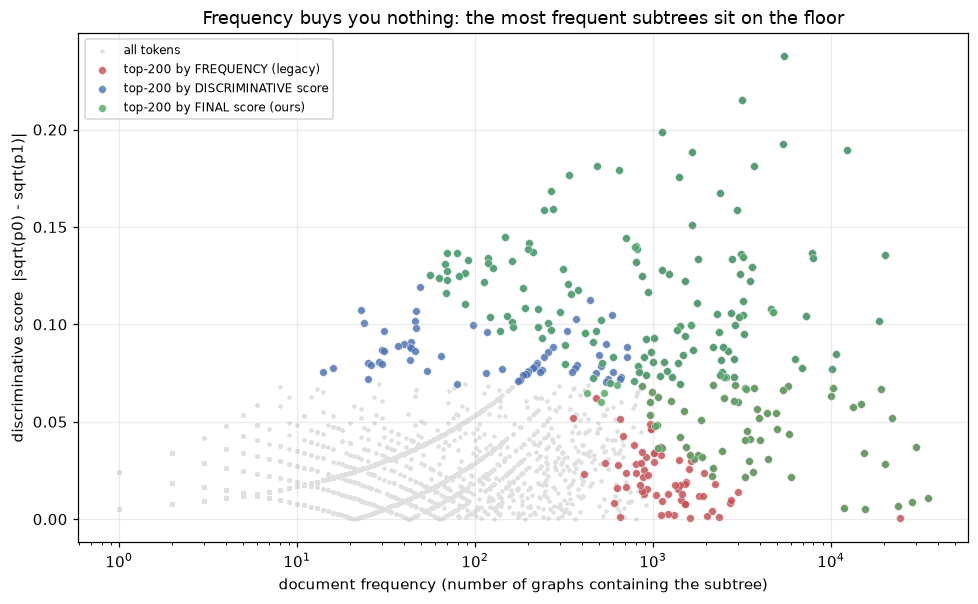

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.6))
ax.scatter(stats.df, stats.disc, s=4, c="#e0e0e0", label="all tokens")

for col, colour, name in [("tf", "#C44E52", "top-200 by FREQUENCY (legacy)"),
                          ("disc", "#4C72B0", "top-200 by DISCRIMINATIVE score"),
                          ("final", "#55A868", "top-200 by FINAL score (ours)")]:
    top = stats.nlargest(224, col)
    ax.scatter(top.df, top.disc, s=26, c=colour, label=name, alpha=.8,
               edgecolors="white", linewidths=.3)

ax.set_xscale("log")
ax.set_xlabel("document frequency (number of graphs containing the subtree)")
ax.set_ylabel("discriminative score  |sqrt(p0) - sqrt(p1)|")
ax.set_title("Frequency buys you nothing: the most frequent subtrees sit on the floor")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()

# print(stats.assign(rank_by=lambda d: None).pipe(lambda _: pd.DataFrame({
#     "selection": ["frequency (legacy)", "discriminative only", "final score (ours)"],
#     "median df of top-100":  [stats.nlargest(100, c).df.median()   for c in ["tf", "disc", "final"]],
#     "mean disc. of top-100": [stats.nlargest(100, c).disc.mean()   for c in ["tf", "disc", "final"]],
#     "% favouring active":    [100*(stats.nlargest(100, c).favours == 1).mean() for c in ["tf", "disc", "final"]],
# })).round(3).to_string(index=False))

`mean − std` is **negative** because the score distribution is heavy-tailed (`std` is 13× `mean`),
so every token passes and no trimming happens. It is not a tuning problem — with a right-skewed
distribution this rule can never trim. Worse, `self.n_vocab = len(trimmed_vocab)` then rewrites the
hyper-parameter to 14,790 and `calc_coefficients` tries `np.zeros((37349, 14790))` = **4.4 GB**.

Your proposed replacement (vocabulary size as an explicit hyper-parameter / decile) is the right
call. The sweep below tells you which decile to pick. **Slow cell (~4 min).**

---
## Do minority-class features survive the trimming?

The absolute value in `|sqrt(p1) - sqrt(p0)|` throws away *which* class a subtree points at. Drop
the absolute value and the score becomes **signed**:

$$ s(w) \;=\; \sqrt{p_{\text{active}}(w)} - \sqrt{p_{\text{inactive}}(w)} $$

* `s < 0` → the subtree is enriched in the **majority** (inactive) class
* `s > 0` → the subtree is enriched in the **minority** (active) class

Horizontal axis = signed score, vertical axis = total frequency. Grey = every WL subtree;
coloured = the 1000 subtrees each rule actually keeps.

,selection,kept majority-biased,kept minority-biased,% minority-biased,median signed score
0,legacy — frequency top-1000,603,397,39.7,-0.013
1,ours — final score top-1000,459,541,54.1,0.015


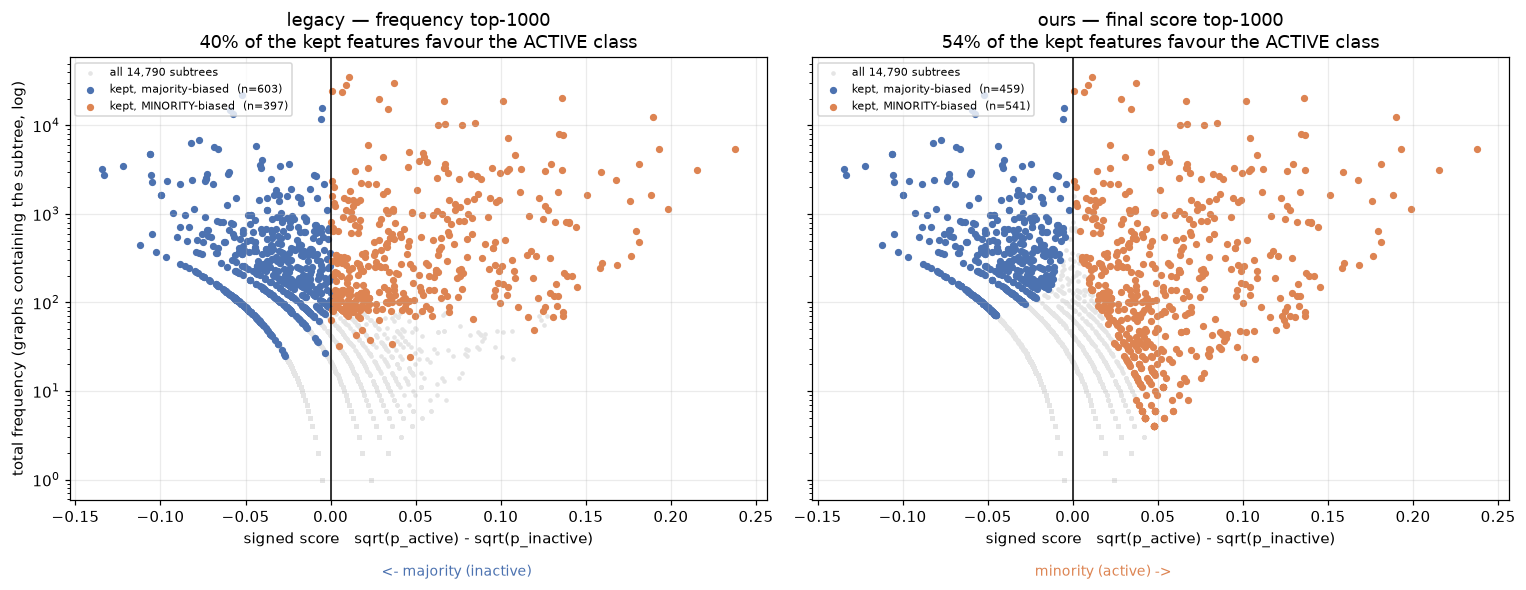

In [28]:
stats["signed"] = np.sqrt(stats.p1) - np.sqrt(stats.p0)     # no absolute value

SEL = {
    "legacy — frequency top-1000": set(stats.nlargest(1000, "tf").token),
    "ours — final score top-1000": set(stats.nlargest(1000, "final").token),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4), sharex=True, sharey=True)
for ax, (name, sel) in zip(axes, SEL.items()):
    keep = stats[stats.token.isin(sel)]
    ax.scatter(stats.signed, stats.df, s=4, c="#e5e5e5", label="all 14,790 subtrees")
    neg, pos = keep[keep.signed < 0], keep[keep.signed >= 0]
    ax.scatter(neg.signed, neg.df, s=14, c="#4C72B0", label=f"kept, majority-biased  (n={len(neg)})")
    ax.scatter(pos.signed, pos.df, s=14, c="#DD8452", label=f"kept, MINORITY-biased  (n={len(pos)})")
    ax.axvline(0, c="k", lw=1)
    ax.set_yscale("log")
    ax.set_xlabel("signed score   sqrt(p_active) - sqrt(p_inactive)")
    ax.set_title(f"{name}\n{100*len(pos)/len(keep):.0f}% of the kept features favour the ACTIVE class")
    ax.legend(fontsize=7, loc="upper left")
axes[0].set_ylabel("total frequency (graphs containing the subtree, log)")
fig.text(.30, .02, "<- majority (inactive)", ha="center", fontsize=9, color="#4C72B0")
fig.text(.72, .02, "minority (active) ->", ha="center", fontsize=9, color="#DD8452")
fig.tight_layout(rect=[0, .04, 1, 1])

pd.DataFrame({
    "selection": list(SEL),
    "kept majority-biased": [int((stats[stats.token.isin(s)].signed < 0).sum()) for s in SEL.values()],
    "kept minority-biased": [int((stats[stats.token.isin(s)].signed >= 0).sum()) for s in SEL.values()],
    "% minority-biased":    [100*(stats[stats.token.isin(s)].signed >= 0).mean() for s in SEL.values()],
    "median signed score":  [stats[stats.token.isin(s)].signed.median() for s in SEL.values()],
}).round(3)

### What this shows

* **Minority features are not being discarded.** Of the 1000 subtrees the final score keeps, **~55%
  are minority-biased**; the frequency rule keeps only **~39%**. Both classes are represented after
  trimming, with a slight tilt *toward* the active class — the opposite of the failure mode the
  method was designed to avoid.
* The kept features spread along the *whole* signed axis, including the far positive tail — the
  strongly active-specific substructures. The frequency rule, by contrast, clusters everything near
  `s = 0` at the top of the frequency axis: high-frequency, no class signal.
* Note the shape of the grey cloud: it is a **funnel**. Large |signed score| is only reachable at
  moderate frequency, because `|s| ≤ sqrt(df / n_active)`. Low-frequency noise physically cannot
  reach the edges — the same bound as in Plot 1, seen from the side.

---
## 6. Square root or no square root?

Two candidates for the discriminative term:

| | formula | interpretation |
|---|---|---|
| **sqrt (current)** | `\|sqrt(p1) - sqrt(p0)\|` | Hellinger distance between the two class-conditional Bernoulli marginals — a proper, bounded metric between distributions |
| **linear** | `\|p1 - p0\|` | plain difference in class-conditional document frequency (total-variation-like) |

The square root is a **variance-stabilising transform**: it magnifies differences near `p = 0` and
compresses them near `p = 1`. So `sqrt` should prefer *rarer, more class-specific* substructures and
`linear` should prefer *more common* ones. That is exactly what happens — the question is whether it
pays. Same leak-free protocol, three budgets. **(~3 min)**

In [ ]:
VARIANTS = {
    "disc, sqrt   |sqrt(p1)-sqrt(p0)|": lambda s: s.disc,                       # current
    "disc, linear |p1-p0|":             lambda s: (s.p1 - s.p0).abs(),
    "final, sqrt  (OURS)":              lambda s: s.final,
    "final, linear":                    lambda s: s.presence * (s.p1 - s.p0).abs(),
}

rows = []
for K in [250, 1000, 4000]:
    acc = defaultdict(lambda: defaultdict(list))
    for tr, te in StratifiedKFold(N_SPLITS, shuffle=True, random_state=SEED).split(np.zeros(len(y)), y):
        fs = token_table(tr)
        for name, fn in VARIANTS.items():
            vocab = list(fs.assign(_s=fn(fs)).nlargest(K, "_s").token)
            for m, v in probe(vocab, tr, te).items():
                acc[name][m].append(v)
            sub = fs[fs.token.isin(set(vocab))]
            acc[name]["median_df"].append(sub.df.median())
            acc[name]["%minority"].append(100 * (sub.p1 > sub.p0).mean())
    for name, d in acc.items():
        rows.append({"k": K, "score": name,
                     "mcc": f"{np.mean(d['mcc']):.4f} ± {np.std(d['mcc']):.4f}",
                     "pr_auc": f"{np.mean(d['pr_auc']):.4f} ± {np.std(d['pr_auc']):.4f}",
                     "minority_f1": round(float(np.mean(d["minority_f1"])), 4),
                     "median_df": round(float(np.mean(d["median_df"])), 1),
                     "% minority": round(float(np.mean(d["%minority"])), 1)})

pd.DataFrame(rows).set_index(["k", "score"])

### Verdict: keep the square root, but for the *right* reason

Measured (mean ± std over the 5 folds):

| budget | score | MCC | PR-AUC | median df of selection |
|---|---|---|---|---|
| 250 | sqrt | 0.315 | **0.381** | 288 |
| 250 | linear | **0.322** | 0.357 | 786 |
| 1000 | sqrt | 0.373 | 0.422 | 58 |
| 1000 | linear | **0.382** | 0.421 | 141 |
| 4000 | sqrt | 0.412 | 0.441 | 11 |
| 4000 | linear | **0.420** | **0.448** | 16 |

**The performance difference is inside the fold-to-fold noise** (the ±std is ~0.01–0.02, and the gaps
are ~0.005–0.01). Anyone claiming the square root gives a performance gain here would be
over-reading the data — it does not, and neither does its removal.

What the square root *does* do, reliably, is change **what gets selected**: it pushes the selection
toward rarer, more class-specific substructures (median df 58 vs 141 at k=1000). Whether that is
desirable depends on your goal:

* **Keep `sqrt`** if you want the score to be a *principled distance between the class-conditional
  distributions* — Hellinger is a bounded metric, it is what Cieslak et al. use for imbalanced
  splitting criteria, and it is what you can defend in a paper. It also gives you the clean
  `|s| ≤ sqrt(df/n_active)` bound that makes the noise argument rigorous.
* **Use `linear`** only if you specifically want commoner substructures, in which case say so —
  but then note that `linear × presence` is close to a frequency-weighted rule, which is what you
  were trying to get away from.

Recommendation: **keep the square root**, report this ablation as a negative result ("performance is
insensitive to the choice; we retain the Hellinger form for its distributional interpretation and
its rare-token bound"), and spend the argument budget on decisions 1 and 2, where the effects are
real.